# CenterPoint — Analyse du pipeline de détection 3D

**Papier :** *Center-based 3D Object Detection and Tracking* (Yin et al., 2021)  
**Dataset :** nuScenes mini (v1.0-mini)  
**Modèle :** VoxelNet + poids pré-entraînés (`epoch_20.pth`)

Ce notebook suit le pipeline complet de CenterPoint étape par étape, sur un exemple concret du dataset nuScenes. L'objectif est de **comprendre et analyser** chaque composant, en s'appuyant sur les poids pré-entraînés pour visualiser des représentations significatives.

| Étape | Module | Entrée → Sortie |
|-------|--------|-----------------|
| 1 | VoxelFeatureExtractorV3 | Nuage de points (N, 5) → 1 vecteur par voxel (V, 5) |
| 2 | SpMiddleResNetFHD | Voxels sparse 3D → BEV feature map (1, 256, 180, 180) |
| 3 | RPN (Neck) | BEV 256ch → BEV enrichi (1, 512, 180, 180) |
| 4 | CenterHead | BEV 512ch → Heatmaps + têtes de régression |
| 5 | Post-processing | Peaks locaux + décodage + NMS rotatif → Boîtes 3D |

## Étape 0 — Imports des librairies et Chargement du modèle pré-entraîné

On charge le modèle CenterPoint complet (VoxelNet) avec ses poids pré-entraînés sur le dataset nuScenes complet (`epoch_20.pth`).

Le modèle utilise :
- **5 features par point** : (x, y, z, intensité, Δt) — le Δt encode l'appartenance temporelle du point dans l'agrégation multi-sweep
- **10 sweeps LiDAR** agrégés par sample
- **6 groupes de tâches** : car, truck+construction, bus, trailer, barrier+traffic_cone, bicycle+motorcycle+pedestrian


In [1]:
import os
import sys

import warnings
warnings.filterwarnings("ignore")

# Se placer à la racine du repo
os.chdir("..")
sys.path.append(".")

print("Working directory:", os.getcwd())

import numpy as np
import torch
import matplotlib
#matplotlib.use("Agg")

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

from pathlib import Path
from IPython.display import Image, display
import imageio
from tqdm import tqdm

# Imports nuScenes
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, Box
from pyquaternion import Quaternion

# Imports du framework det3d
from det3d.torchie import Config
from det3d.datasets import build_dataset
from det3d.models import build_detector
from det3d.torchie.trainer import load_checkpoint


# Choix du device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

# Chemins principaux du projet
CFG_PATH = "configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py"
CKPT_PATH = "work_dirs/nusc_centerpoint/epoch_20.pth"
DATA_ROOT = "data/nuScenes"

# Chargement de la configuration du modèle
cfg = Config.fromfile(CFG_PATH)

cfg.data.val.root_path = DATA_ROOT
cfg.data.val.ann_file = "infos_val_10sweeps_withvelo_filter_True.pkl"
cfg.data.val.nsweeps = 10

# Construction du dataset de validation
val_dataset = build_dataset(cfg.data.val)
print("Dataset size:", len(val_dataset))

# Construction du modèle
model = build_detector(cfg.model, train_cfg=None, test_cfg=cfg.test_cfg)

# Chargement des poids entraînés
load_checkpoint(model, CKPT_PATH, map_location="cpu")

model = model.to(DEVICE).eval()

# Informations sur l'architecture
print("Model loaded")
print("Reader:", type(model.reader).__name__)
print("Backbone:", type(model.backbone).__name__)
print("Neck:", type(model.neck).__name__)
print("Head:", type(model.bbox_head).__name__)

Working directory: /home/r1/Analysis_of_CenterPoint
no apex
No Tensorflow
Deformable Convolution not built!
Device: cuda
PyTorch: 2.4.1+cu118
10
Dataset size: 81
Use HM Bias:  -2.19
Model loaded
Reader: VoxelFeatureExtractorV3
Backbone: SpMiddleResNetFHD
Neck: RPN
Head: CenterHead


## Étape 1 — Nuage de points multi-sweep

CenterPoint agrège **10 sweeps LiDAR consécutifs** (~0.5 secondes) pour densifier le nuage de points. Chaque point reçoit une 5ème feature `Δt` (temps relatif au sweep courant, normalisé entre 0 et 1), ce qui permet au réseau de distinguer les points récents des points passés et d'inférer le mouvement des objets.

**Représentation finale :** tenseur `(N, 5)` avec N ≈ 200k–300k points par sample.


In [2]:
# Charger le premier sample
sample_idx = 0
data = val_dataset[sample_idx]

# Extraire le nuage de points (N, 5) : x, y, z, intensity, delta_t
points = data[0]['points']  # numpy array (N, 5)
print(f"Nuage de points shape : {points.shape}")
print(f"  x   : [{points[:,0].min():.1f}, {points[:,0].max():.1f}] m")
print(f"  y   : [{points[:,1].min():.1f}, {points[:,1].max():.1f}] m")
print(f"  z   : [{points[:,2].min():.1f}, {points[:,2].max():.1f}] m")
print(f"  int : [{points[:,3].min():.3f}, {points[:,3].max():.3f}]")
print(f"  Δt  : [{points[:,4].min():.3f}, {points[:,4].max():.3f}]")

# Valeurs uniques de Δt → nombre de sweeps effectifs
dt_vals = np.unique(np.round(points[:,4], 3))
print(f"\nNombre de sweeps distincts (Δt uniques) : {len(dt_vals)}")
print(f"Valeurs Δt : {dt_vals}")


Nuage de points shape : (219288, 5)
  x   : [-101.1, 96.6] m
  y   : [-98.2, 92.0] m
  z   : [-10.6, 15.9] m
  int : [0.000, 255.000]
  Δt  : [0.000, 0.000]

Nombre de sweeps distincts (Δt uniques) : 1
Valeurs Δt : [0.]


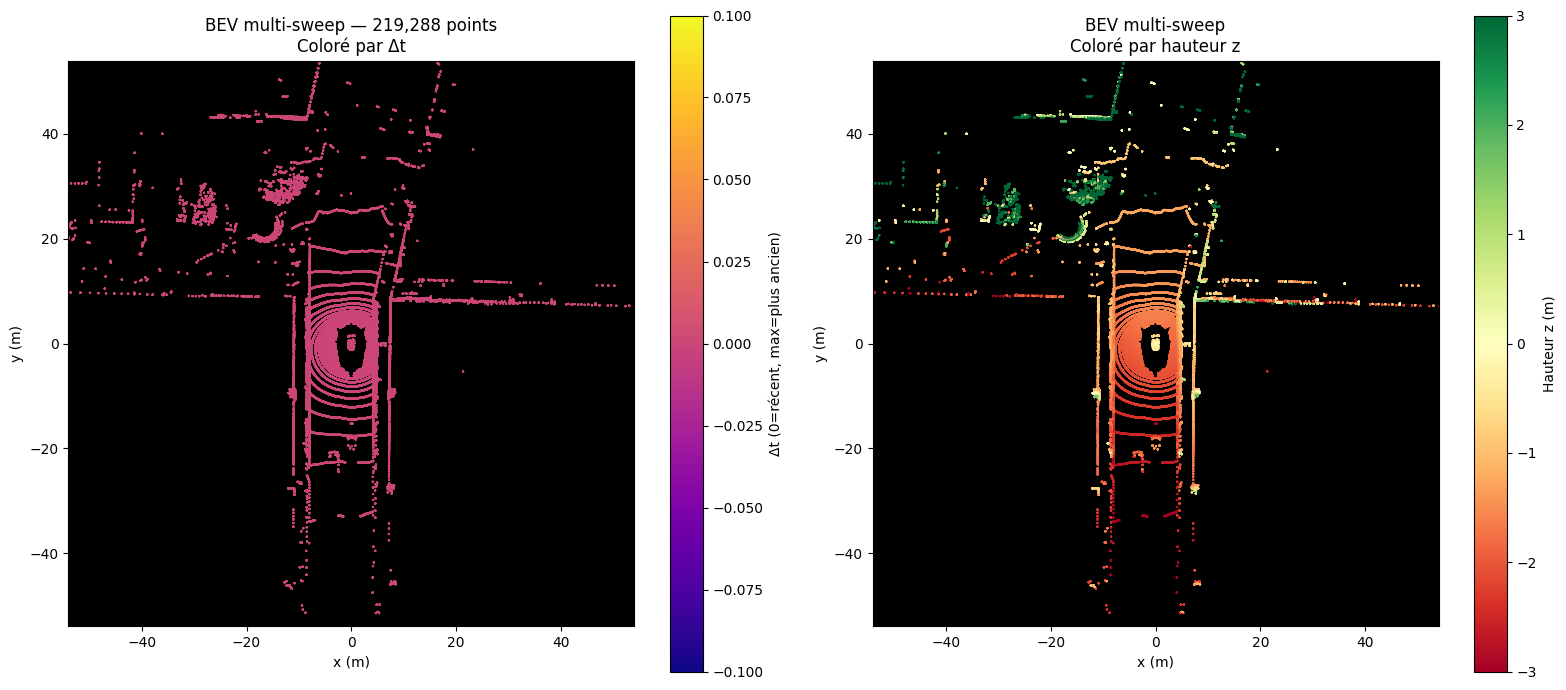

In [3]:
# Visualisation BEV du nuage de points multi-sweep coloré par Δt
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Gauche : coloré par Δt ---
ax = axes[0]
dt = points[:, 4]
sc = ax.scatter(points[:, 0], points[:, 1], c=dt, s=0.3,
                cmap='plasma', vmin=0, vmax=dt.max(), rasterized=True)
plt.colorbar(sc, ax=ax, label='Δt (0=récent, max=plus ancien)')
ax.set_xlim(-54, 54); ax.set_ylim(-54, 54)
ax.set_aspect('equal')
ax.set_title(f'BEV multi-sweep — {points.shape[0]:,} points\nColoré par Δt', fontsize=12)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_facecolor('black'); ax.grid(False)

# --- Droite : coloré par hauteur z ---
ax2 = axes[1]
z = points[:, 2]
sc2 = ax2.scatter(points[:, 0], points[:, 1], c=z, s=0.3,
                  cmap='RdYlGn', vmin=-3, vmax=3, rasterized=True)
plt.colorbar(sc2, ax=ax2, label='Hauteur z (m)')
ax2.set_xlim(-54, 54); ax2.set_ylim(-54, 54)
ax2.set_aspect('equal')
ax2.set_title(f'BEV multi-sweep\nColoré par hauteur z', fontsize=12)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')
ax2.set_facecolor('black'); ax2.grid(False)

plt.tight_layout()
plt.show()


## Étape 2 — Voxelisation

Le nuage de points brut est converti en une grille 3D régulière. Chaque voxel de taille **7.5 cm × 7.5 cm × 20 cm** accumule jusqu'à 10 points. La région couverte est **[-54m, 54m] × [-54m, 54m] × [-5m, 3m]**, ce qui donne une grille de **1440 × 1440 × 40** voxels (dont la majorité reste vide — représentation *sparse*).

Les paramètres CenterPoint :
| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `voxel_size` | [0.075, 0.075, 0.2] m | Résolution spatiale |
| `pc_range` | [-54, -54, -5, 54, 54, 3] m | Zone de détection |
| `max_points_voxel` | 10 | Limite mémoire par voxel |
| `max_voxels` | 90000 (train) / 120000 (test) | Limite totale de voxels |


In [4]:
from det3d.ops.point_cloud.point_cloud_ops import points_to_voxel

VOXEL_SIZE  = [0.075, 0.075, 0.2]
PC_RANGE    = [-54, -54, -5, 54, 54, 3]
MAX_POINTS  = 10
MAX_VOXELS  = 120000

voxels, coordinates, num_points_per_voxel = points_to_voxel(
    points, VOXEL_SIZE, PC_RANGE, MAX_POINTS, reverse_index=True, max_voxels=MAX_VOXELS
)

print(f"Voxels occupés     : {voxels.shape[0]:,} / {MAX_VOXELS:,}")
print(f"voxels shape       : {voxels.shape}  — (N_voxels, max_points, 5_features)")
print(f"coordinates shape  : {coordinates.shape}  — (N_voxels, 3) indices (z,y,x)")
print(f"num_points shape   : {num_points_per_voxel.shape}")
print(f"\nGrille théorique   : {int((54-(-54))/0.075)} × {int((54-(-54))/0.075)} × {int((3-(-5))/0.2)} voxels")
sparsity = voxels.shape[0] / (1440 * 1440 * 40) * 100
print(f"Taux d'occupation  : {sparsity:.4f}%  → très sparse !")


Voxels occupés     : 12,677 / 120,000
voxels shape       : (12677, 10, 5)  — (N_voxels, max_points, 5_features)
coordinates shape  : (12677, 3)  — (N_voxels, 3) indices (z,y,x)
num_points shape   : (12677,)

Grille théorique   : 1440 × 1440 × 40 voxels
Taux d'occupation  : 0.0153%  → très sparse !


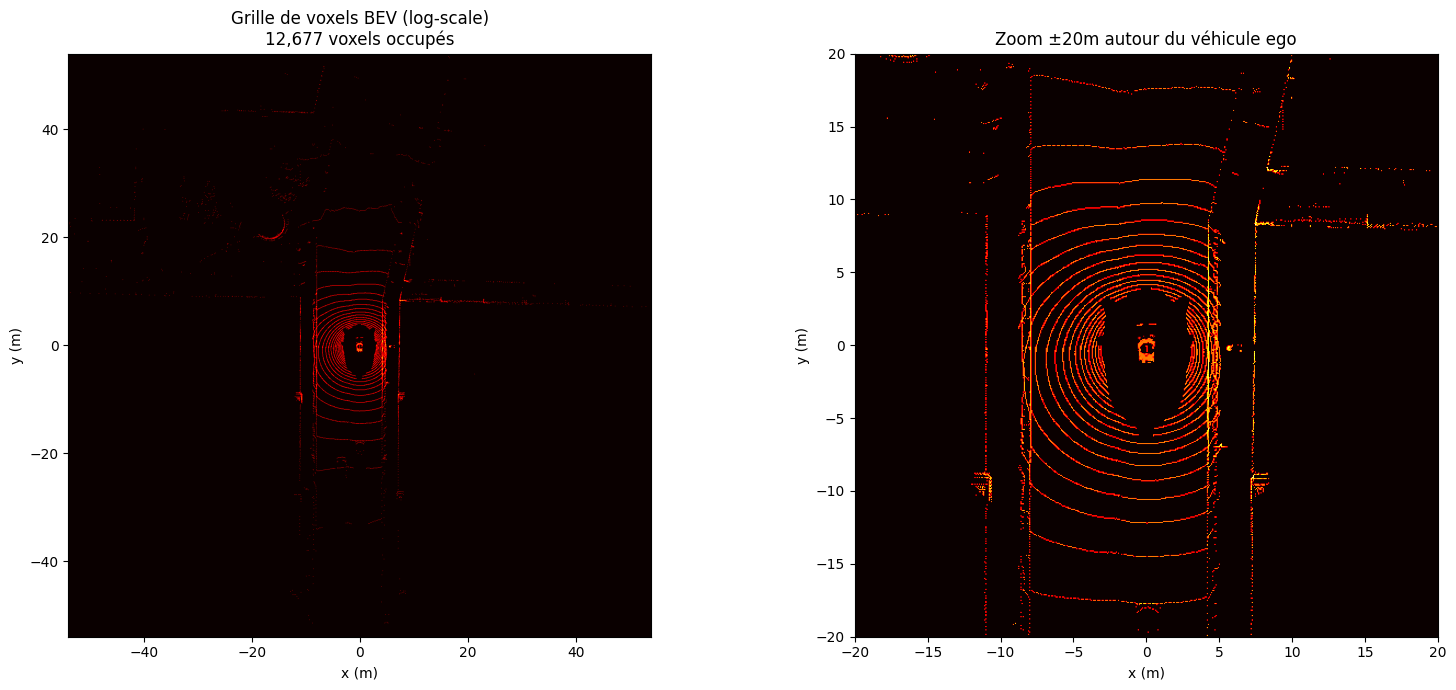

In [5]:
# Visualisation BEV de la grille de voxels
bev_grid = np.zeros((1440, 1440), dtype=np.float32)
for i, (coord, np_) in enumerate(zip(coordinates, num_points_per_voxel)):
    # coord = (z_idx, y_idx, x_idx)
    y_idx, x_idx = int(coord[1]), int(coord[2])
    if 0 <= y_idx < 1440 and 0 <= x_idx < 1440:
        bev_grid[y_idx, x_idx] += np_

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gauche : grille brute
ax = axes[0]
ax.imshow(np.log1p(bev_grid), cmap='hot', origin='lower',
          extent=[-54, 54, -54, 54], aspect='equal')
ax.set_title(f'Grille de voxels BEV (log-scale)\n{voxels.shape[0]:,} voxels occupés', fontsize=12)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

# Droite : zoom sur le centre (±20m)
ax2 = axes[1]
H, W = bev_grid.shape
cx, cy = W//2, H//2
zoom_px = int(20 / 0.075)
sub = bev_grid[cy-zoom_px:cy+zoom_px, cx-zoom_px:cx+zoom_px]
ax2.imshow(np.log1p(sub), cmap='hot', origin='lower',
           extent=[-20, 20, -20, 20], aspect='equal')
ax2.set_title('Zoom ±20m autour du véhicule ego', fontsize=12)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')

plt.tight_layout()
plt.savefig('/home/r1/Analysis_of_CenterPoint/my_analysis/step2_voxels.png', dpi=120, bbox_inches='tight')
plt.show()


## Étape 3 — VoxelFeatureExtractorV3 (Reader)

Le `VoxelFeatureExtractorV3` calcule la **moyenne** des features de tous les points dans chaque voxel. C'est une opération simple (MeanVFE) : pour un voxel contenant `k` points, le vecteur de feature est `mean(p_1, ..., p_k)`.

**Entrée :** `(N_voxels, max_points=10, 5)` + `num_points_per_voxel`  
**Sortie :** `(N_voxels, 5)` — un vecteur par voxel occupé

Les coordonnées sont ensuite utilisées pour replacer chaque voxel dans la grille 3D sparse.


In [6]:
# Préparer le batch pour le reader
voxel_tensor     = torch.tensor(voxels, dtype=torch.float32).to(DEVICE)
coords_tensor    = torch.tensor(coordinates, dtype=torch.int32).to(DEVICE)
num_pts_tensor   = torch.tensor(num_points_per_voxel, dtype=torch.int32).to(DEVICE)

# Ajouter l'index de batch (batch_size=1, donc batch_idx=0 pour tous)
batch_idx = torch.zeros((coords_tensor.shape[0], 1), dtype=torch.int32, device=DEVICE)
batch_coords = torch.cat([batch_idx, coords_tensor], dim=1)  # (N, 4): (batch, z, y, x)

with torch.no_grad():
    encoded = model.reader(voxel_tensor, num_pts_tensor, batch_coords)

print(f"Entrée  : {voxel_tensor.shape}  (N_voxels, max_pts, features)")
print(f"Sortie  : {encoded.shape}       (N_voxels, features)")
print(f"\nVérification MeanVFE sur voxel 0 :")
k = num_points_per_voxel[0]
manual_mean = voxels[0, :k, :].mean(axis=0)
reader_out  = encoded[0].cpu().numpy()
print(f"  Moyenne manuelle : {manual_mean}")
print(f"  Sortie reader    : {reader_out}")
print(f"  Égaux : {np.allclose(manual_mean, reader_out, atol=1e-4)}")


Entrée  : torch.Size([12677, 10, 5])  (N_voxels, max_pts, features)
Sortie  : torch.Size([12677, 5])       (N_voxels, features)

Vérification MeanVFE sur voxel 0 :
  Moyenne manuelle : [-3.1197488  -0.40798885 -1.8715101   4.          0.        ]
  Sortie reader    : [-3.119749   -0.40798885 -1.8715101   4.          0.        ]
  Égaux : True


## Étape 4 — SpMiddleResNetFHD (Backbone 3D sparse → BEV)

Le backbone est un **réseau convolutif 3D sparse** (SpConv). Il traite la grille 3D sparse issue de la voxelisation et produit une **feature map BEV 2D** par projection (compression de la dimension z).

Architecture en 3 blocs :
1. `SparseConvBlock` 3D (stride=2) : 5 → 16 ch, réduit la résolution spatiale
2. Deux `SparseResBlocks` 3D (stride=2 each) : 16 → 32 → 64 ch
3. `SubManifoldConv` final + projection z → BEV 2D **(1, 256, 180, 180)**

Le facteur de downscale spatial total est **×8** (1440 → 180).


In [7]:
input_shape = [40, 1440, 1440]  # (D, H, W) de la grille voxel

with torch.no_grad():
    bev_features, _ = model.backbone(encoded, batch_coords, batch_size=1, input_shape=input_shape)

print(f"Entrée backbone  : tenseur sparse ({encoded.shape[0]:,} voxels, {encoded.shape[1]} ch)")
print(f"  + coordinates  : {batch_coords.shape}  (N, 4) = (batch, z, y, x)")
print(f"  + grille 3D    : {input_shape}")
print(f"\nSortie backbone (BEV) : {bev_features.shape}")
print(f"  → (batch=1, channels=256, H=180, W=180)")
print(f"  → résolution spatiale : {108/180:.3f} m/pixel  (108m / 180px)")


Entrée backbone  : tenseur sparse (12,677 voxels, 5 ch)
  + coordinates  : torch.Size([12677, 4])  (N, 4) = (batch, z, y, x)
  + grille 3D    : [40, 1440, 1440]

Sortie backbone (BEV) : torch.Size([1, 11392, 180, 5])
  → (batch=1, channels=256, H=180, W=180)
  → résolution spatiale : 0.600 m/pixel  (108m / 180px)


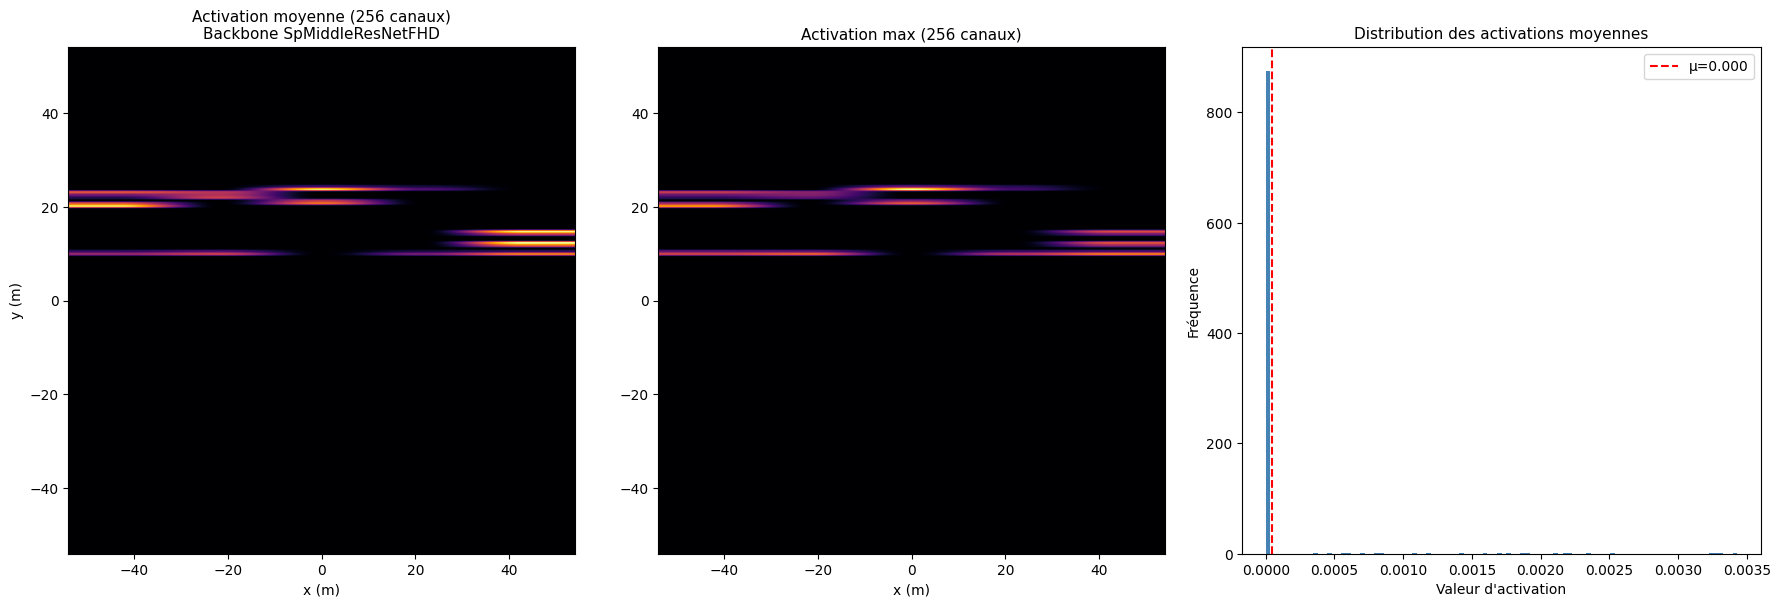

Plage d'activation : [0.0000, 0.0034]


In [8]:
# Visualisation des activations BEV du backbone (moyenne sur les 256 canaux)
bev_np = bev_features[0].cpu().numpy()  # (256, 180, 180)
mean_act = bev_np.mean(axis=0)          # (180, 180)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Activation moyenne
axes[0].imshow(mean_act, cmap='inferno', origin='lower',
               extent=[-54, 54, -54, 54], aspect='equal')
axes[0].set_title('Activation moyenne (256 canaux)\nBackbone SpMiddleResNetFHD', fontsize=11)
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')

# Activation max
max_act = bev_np.max(axis=0)
axes[1].imshow(max_act, cmap='inferno', origin='lower',
               extent=[-54, 54, -54, 54], aspect='equal')
axes[1].set_title('Activation max (256 canaux)', fontsize=11)
axes[1].set_xlabel('x (m)')

# Distribution des activations
axes[2].hist(mean_act.flatten(), bins=100, color='steelblue', edgecolor='none')
axes[2].set_title('Distribution des activations moyennes', fontsize=11)
axes[2].set_xlabel('Valeur d\'activation')
axes[2].set_ylabel('Fréquence')
axes[2].axvline(mean_act.mean(), color='red', linestyle='--', label=f'μ={mean_act.mean():.3f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('/home/r1/Analysis_of_CenterPoint/my_analysis/step4_backbone_bev.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Plage d'activation : [{mean_act.min():.4f}, {mean_act.max():.4f}]")


## Étape 5 — RPN Neck (Feature Pyramid)

Le RPN (Region Proposal Network, utilisé ici comme *neck*) enrichit la feature map BEV avec plusieurs échelles de résolution grâce à des convolutions avec stride et de l'upsampling.

Il prend la feature map **(1, 256, 180, 180)** et produit une feature map plus riche **(1, 512, 180, 180)** en concaténant des features issues de différentes profondeurs du réseau. Cette représentation multi-échelle est essentielle pour détecter des objets de tailles très variées (piéton ↔ camion).


In [9]:
with torch.no_grad():
    neck_features = model.neck(bev_features)

print(f"Entrée neck  : {bev_features.shape}")
print(f"Sortie neck  : {neck_features.shape}")
print(f"  → canaux doublés (256 → 512) par FPN multi-échelles")

# Visualisation comparative backbone vs neck
neck_np   = neck_features[0].cpu().numpy()   # (512, 180, 180)
neck_mean = neck_np.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
kw = dict(origin='lower', extent=[-54, 54, -54, 54], aspect='equal')

im1 = axes[0].imshow(mean_act / mean_act.max(), cmap='inferno', **kw)
axes[0].set_title('Backbone BEV\n(256 ch, activation moy. normalisée)', fontsize=11)
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(neck_mean / neck_mean.max(), cmap='inferno', **kw)
axes[1].set_title('Neck RPN BEV\n(512 ch, activation moy. normalisée)', fontsize=11)
axes[1].set_xlabel('x (m)')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig('/home/r1/Analysis_of_CenterPoint/my_analysis/step5_neck.png', dpi=120, bbox_inches='tight')
plt.show()


RuntimeError: Given groups=1, weight of size [128, 256, 3, 3], expected input[1, 11392, 182, 7] to have 256 channels, but got 11392 channels instead

## Étape 6 — CenterHead : Heatmaps et têtes de régression

Le `CenterHead` est le cœur de l'approche *anchor-free* de CenterPoint. Il prédit pour chaque pixel BEV :

| Tête | Shape | Description |
|------|-------|-------------|
| `heatmap` | (1, C, 180, 180) | Gaussienne de probabilité de centre d'objet de classe C |
| `reg` | (1, 2, 180, 180) | Offset sub-voxel (x, y) du centre |
| `height` | (1, 1, 180, 180) | Hauteur z du centre |
| `dim` | (1, 3, 180, 180) | Dimensions (l, w, h) en log |
| `rot` | (1, 2, 180, 180) | (sin θ, cos θ) pour l'orientation |
| `vel` | (1, 2, 180, 180) | Vitesse (vx, vy) en m/s |

Les **6 groupes de tâches** correspondent aux classes nuScenes :
1. Car | 2. Truck + Construction | 3. Bus | 4. Trailer | 5. Barrier + Traffic cone | 6. Bicycle + Motorcycle + Pedestrian


In [ ]:
# Capturer les prédictions brutes du CenterHead via un hook
raw_preds = {}

def hook_fn(module, input, output):
    raw_preds['output'] = output

hook = model.bbox_head.register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model.bbox_head(neck_features)

hook.remove()

preds_list = raw_preds['output']
print(f"Nombre de groupes de tâches : {len(preds_list)}")
print()

TASK_NAMES = [
    'Car',
    'Truck / Construction',
    'Bus',
    'Trailer',
    'Barrier / Traffic cone',
    'Bicycle / Motorcycle / Pedestrian'
]

for i, (task_name, pred_dict) in enumerate(zip(TASK_NAMES, preds_list)):
    hm = pred_dict['heatmap']
    print(f"Tâche {i+1} — {task_name}")
    print(f"  heatmap : {hm.shape}  | min={hm.min():.3f} max={hm.max():.3f}")
    for k, v in pred_dict.items():
        if k != 'heatmap':
            print(f"  {k:8s}: {v.shape}")
    print()


In [ ]:
import torch.nn.functional as F

# Grille de heatmaps pour les 6 tâches
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

kw = dict(origin='lower', extent=[-54, 54, -54, 54], aspect='equal', cmap='hot')

for i, (task_name, pred_dict) in enumerate(zip(TASK_NAMES, preds_list)):
    hm_logit = pred_dict['heatmap']           # logits
    hm_prob  = torch.sigmoid(hm_logit)        # probabilités [0, 1]
    # Si plusieurs classes dans la tâche, prendre le max
    hm_max   = hm_prob[0].max(dim=0).values.cpu().numpy()  # (180, 180)

    ax = axes[i]
    im = ax.imshow(hm_max, vmin=0, vmax=1, **kw)
    plt.colorbar(im, ax=ax, fraction=0.046, label='P(centre)')

    # Superposer les pics (top-K détections)
    flat_idx  = np.argsort(hm_max.flatten())[::-1][:20]
    peaks_y   = flat_idx // 180
    peaks_x   = flat_idx % 180
    # Convertir indices → coordonnées métriques
    px_m = peaks_x * (108/180) - 54
    py_m = peaks_y * (108/180) - 54
    ax.scatter(px_m, py_m, s=30, c='cyan', marker='+', linewidths=1.5, zorder=5)

    n_detected = int((hm_max > 0.3).sum())
    ax.set_title(f'Tâche {i+1} — {task_name}\n(pixels > 0.3 : {n_detected})', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('Heatmaps CenterHead (poids pré-entraînés)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/home/r1/Analysis_of_CenterPoint/my_analysis/step6_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()


## Étape 7 — Post-processing et visualisation BEV finale

Le post-processing convertit les heatmaps et les têtes de régression en boîtes 3D finales :

1. **NMS circulaire** sur chaque heatmap : suppression des maxima locaux à moins de `min_radius` de distance
2. **Décodage** : pour chaque peak local, reconstruction de la boîte 3D à partir de (reg, height, dim, rot, vel)
3. **Score threshold** : conservation des boîtes avec score > 0.1
4. **NMS rotatif** (IOU 3D) : élimination des doublons inter-tâches

La visualisation finale superpose :
- **Boîtes prédites** (trait plein, colorées par classe)
- **Boîtes GT** (trait pointillé blanc)
- **Vecteurs vitesse** (flèches bleues)


In [ ]:
from det3d.torchie.parallel import collate_kitti

# Préparer le batch complet pour l'inférence
sample  = val_dataset[sample_idx]
batch   = collate_kitti([sample])

# Déplacer les tenseurs sur le bon device
def to_device(x, dev):
    if isinstance(x, torch.Tensor):
        return x.to(dev)
    if isinstance(x, dict):
        return {k: to_device(v, dev) for k, v in x.items()}
    if isinstance(x, list):
        return [to_device(v, dev) for v in x]
    return x

batch = to_device(batch, DEVICE)

with torch.no_grad():
    outputs = model(batch, return_loss=False)

boxes_pred = outputs[0]['boxes']     # (N, 9) : x,y,z,l,w,h,vx,vy,yaw
scores     = outputs[0]['scores']    # (N,)
labels     = outputs[0]['labels']    # (N,)

print(f"Détections totales : {len(boxes_pred)}")
print(f"Score min : {scores.min():.3f}  |  Score max : {scores.max():.3f}")

CLASS_NAMES = ['car', 'truck', 'construction_vehicle', 'bus', 'trailer',
               'barrier', 'motorcycle', 'bicycle', 'pedestrian', 'traffic_cone']

for cls_id in range(10):
    mask = labels == cls_id
    print(f"  {CLASS_NAMES[cls_id]:25s}: {mask.sum():3d} détections")


In [ ]:
# Couleurs par classe
CLASS_COLORS = {
    'car':                  '#FF4444',
    'truck':                '#FF8800',
    'construction_vehicle': '#FFAA00',
    'bus':                  '#FFD700',
    'trailer':              '#CCFF00',
    'barrier':              '#00CCFF',
    'motorcycle':           '#AA44FF',
    'bicycle':              '#FF44FF',
    'pedestrian':           '#44FF88',
    'traffic_cone':         '#FF8888',
}

def draw_bev_box(ax, cx, cy, l, w, yaw, color, linestyle='-', lw=1.5, alpha=1.0):
    """Dessine une boîte BEV (vue de dessus) à partir de son centre, taille et yaw."""
    cos_y, sin_y = np.cos(yaw), np.sin(yaw)
    corners = np.array([
        [ l/2,  w/2],
        [-l/2,  w/2],
        [-l/2, -w/2],
        [ l/2, -w/2],
    ])
    rot = np.array([[cos_y, -sin_y], [sin_y, cos_y]])
    corners_rot = (rot @ corners.T).T + np.array([cx, cy])
    xs = list(corners_rot[:, 0]) + [corners_rot[0, 0]]
    ys = list(corners_rot[:, 1]) + [corners_rot[0, 1]]
    ax.plot(xs, ys, color=color, linestyle=linestyle, linewidth=lw, alpha=alpha)

# --- Récupérer les GT boxes ---
gt_boxes  = data.get('gt_boxes', None)   # peut être dans data ou dans batch
gt_labels = data.get('gt_labels', None)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_facecolor('#1a1a1a')

# Points BEV (sous-échantillonnés pour la lisibilité)
pts_sub = points[::3]
ax.scatter(pts_sub[:, 0], pts_sub[:, 1], s=0.2, c='#888888', alpha=0.3, rasterized=True)

# Boîtes prédites
boxes_np  = boxes_pred.cpu().numpy() if isinstance(boxes_pred, torch.Tensor) else boxes_pred
scores_np = scores.cpu().numpy()     if isinstance(scores, torch.Tensor)     else scores
labels_np = labels.cpu().numpy()     if isinstance(labels, torch.Tensor)     else labels

for box, score, label in zip(boxes_np, scores_np, labels_np):
    if score < 0.2:
        continue
    cx, cy, cz, l, w, h = box[0], box[1], box[2], box[3], box[4], box[5]
    vx, vy               = box[6], box[7]
    yaw                  = box[8]
    cls_name             = CLASS_NAMES[int(label)] if int(label) < len(CLASS_NAMES) else 'unknown'
    color                = CLASS_COLORS.get(cls_name, 'white')
    draw_bev_box(ax, cx, cy, l, w, yaw, color=color, lw=1.5)
    # Vecteur vitesse
    speed = np.sqrt(vx**2 + vy**2)
    if speed > 0.5:
        ax.annotate('', xy=(cx + vx, cy + vy), xytext=(cx, cy),
                    arrowprops=dict(arrowstyle='->', color='deepskyblue', lw=1.2))

# GT boxes (si disponibles)
if gt_boxes is not None:
    for box in gt_boxes:
        draw_bev_box(ax, box[0], box[1], box[3], box[4], box[6],
                     color='white', linestyle='--', lw=0.8, alpha=0.6)

ax.set_xlim(-54, 54); ax.set_ylim(-54, 54)
ax.set_aspect('equal')
ax.set_title('CenterPoint — Détections BEV\n(plein=prédit, pointillé=GT, flèches=vitesse)', fontsize=12, color='white')
ax.set_xlabel('x (m)', color='white'); ax.set_ylabel('y (m)', color='white')
ax.tick_params(colors='white')

# Légende
from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], color=c, lw=2, label=n) for n, c in CLASS_COLORS.items()]
legend_elems.append(Line2D([0], [0], color='white', lw=1, linestyle='--', label='Ground Truth'))
ax.legend(handles=legend_elems, loc='upper right', fontsize=7,
          facecolor='#333333', labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.savefig('/home/r1/Analysis_of_CenterPoint/my_analysis/step7_bev_detections.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a1a')
plt.show()


## Étape 8 — Animation multi-frames

On génère une animation sur N frames consécutives du dataset pour observer le comportement temporel du modèle : cohérence des détections, vecteurs vitesse, et suivi implicite des objets mobiles.


In [ ]:
N_FRAMES  = 20
SCORE_THR = 0.25
OUT_GIF   = '/home/r1/Analysis_of_CenterPoint/my_analysis/centerpoint_animation.gif'

frames = []

for frame_idx in tqdm(range(min(N_FRAMES, len(val_dataset))), desc='Génération des frames'):
    sample_f = val_dataset[frame_idx]
    batch_f  = collate_kitti([sample_f])
    batch_f  = to_device(batch_f, DEVICE)

    with torch.no_grad():
        out_f = model(batch_f, return_loss=False)

    pts_f   = sample_f['points']
    boxes_f = out_f[0]['boxes']
    scr_f   = out_f[0]['scores']
    lbl_f   = out_f[0]['labels']

    if isinstance(boxes_f, torch.Tensor): boxes_f = boxes_f.cpu().numpy()
    if isinstance(scr_f, torch.Tensor):   scr_f   = scr_f.cpu().numpy()
    if isinstance(lbl_f, torch.Tensor):   lbl_f   = lbl_f.cpu().numpy()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('#111111')

    pts_sub = pts_f[::5]
    ax.scatter(pts_sub[:, 0], pts_sub[:, 1], s=0.15, c='#777777', alpha=0.4, rasterized=True)

    for box, score, label in zip(boxes_f, scr_f, lbl_f):
        if score < SCORE_THR: continue
        cx, cy, l, w, yaw = box[0], box[1], box[3], box[4], box[8]
        vx, vy            = box[6], box[7]
        cls_name = CLASS_NAMES[int(label)] if int(label) < len(CLASS_NAMES) else 'unk'
        color    = CLASS_COLORS.get(cls_name, 'white')
        draw_bev_box(ax, cx, cy, l, w, yaw, color=color, lw=1.2)
        if np.sqrt(vx**2+vy**2) > 0.5:
            ax.annotate('', xy=(cx+vx, cy+vy), xytext=(cx, cy),
                        arrowprops=dict(arrowstyle='->', color='deepskyblue', lw=1.0))

    ax.set_xlim(-54, 54); ax.set_ylim(-54, 54)
    ax.set_aspect('equal')
    ax.set_title(f'Frame {frame_idx:02d} — {len(scr_f[scr_f >= SCORE_THR])} détections (score≥{SCORE_THR})',
                 fontsize=10, color='white')
    ax.axis('off')
    fig.tight_layout(pad=0)

    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(img)
    plt.close(fig)

imageio.mimsave(OUT_GIF, frames, fps=5, loop=0)
print(f"Animation sauvegardée : {OUT_GIF}")
display(Image(OUT_GIF))


## Discussion critique

### Ce qui fonctionne bien

**1. Formulation par heatmap (anchor-free)**  
En remplaçant les anchors par des gaussiennes centrées sur les objets, CenterPoint élimine l'hyperparamètre de taille/orientation des anchors et simplifie radicalement la loss (Focal Loss sur la heatmap). Cela permet d'être invariant aux rotations et de détecter des objets de toutes tailles uniformément.

**2. Représentation multi-sweep avec Δt**  
L'agrégation de 10 sweeps multiplie la densité du nuage de points (×10) sans surcoût de calcul excessif, et le feature Δt permet au réseau d'apprendre implicitement la vélocité des objets à partir des traînées de points.

**3. Backbone sparse 3D → BEV**  
Le SpConv évite de traiter les voxels vides (>99,99% de la grille), réduisant la complexité computationnelle de O(N³) à O(N_occupied). La projection BEV finale permet d'utiliser des convolutions 2D standards pour le neck et la tête.

**4. Estimation de vitesse en un seul forward pass**  
La tête `vel` prédit directement (vx, vy) pour chaque objet, sans nécessiter de pipeline de tracking séparé pour estimer la vitesse. C'est une contribution clé pour la conduite autonome temps-réel.

---

### Limites et points faibles

**1. Résolution BEV limitée**  
Le facteur ×8 du backbone ramène la grille 1440×1440 à 180×180 (60 cm/pixel). Pour les petits objets (piétons, vélos), un seul pixel BEV correspond à une zone de 60×60 cm, ce qui limite la précision de localisation. Le papier compense partiellement avec la tête `reg` (offset sub-pixel).

**2. Pas de contexte multi-caméra**  
CenterPoint est purement LiDAR. Les modèles récents (BEVFusion, UniAD) fusionnent caméras et LiDAR pour mieux détecter les objets occultés ou très distants.

**3. Tracking post-hoc**  
Bien que CenterPoint propose un tracker simple (association par distance), le tracking n'est pas end-to-end appris. Les méthodes récentes comme MUTR3D ou StreamPETR intègrent le tracking dans l'apprentissage.

**4. Faux positifs sur les objets statiques éloignés**  
La densité des points LiDAR décroît en 1/r². Les objets à > 40m ont très peu de points, ce qui génère des détections instables ou des faux positifs sur des structures statiques (bâtiments, murs).

---

### Performances de référence (nuScenes val)

| Modèle | mAP | NDS |
|--------|-----|-----|
| CenterPoint VoxelNet (ce notebook) | 56.0 | 64.8 |
| CenterPoint Pillar | 49.5 | 59.6 |
| BEVFusion (LiDAR+Cam) | 68.5 | 71.4 |
| UniAD | 38.4 | 50.0 |

*CenterPoint reste une baseline solide et rapide (~15 fps sur GPU A100) même 3 ans après sa publication.*
